Questions 1 & 2: p = 0 (no flipping)
Sequence: [1, 0, 1, 0, 1, 0, 1, 0, 1, 0]
  Posterior ratio: 303.7773
  Decision: theta1 (fair)

Sequence: [2, 2, 2, 2, 2, 0, 0, 0, 0, 0]
  Posterior ratio: 3.2473
  Decision: theta1 (fair)

Question 3: p = 0.5 (flipping with probability 0.5)
Sequence: [1, 0, 1, 0, 1, 0, 1, 0, 1, 0]
  Posterior ratio: 7.5282
  Decision: theta1 (fair)

Sequence: [2, 2, 2, 2, 2, 0, 0, 0, 0, 0]
  Posterior ratio: 0.3487
  Decision: theta2 (biased)

Question 3: p = 0.2 (flipping with probability 0.2)
Sequence: [1, 0, 1, 0, 1, 0, 1, 0, 1, 0]
  Posterior ratio: 42.6515
  Decision: theta1 (fair)

Sequence: [2, 2, 2, 2, 2, 0, 0, 0, 0, 0]
  Posterior ratio: 1.2520
  Decision: theta1 (fair)

Generating stem plots...


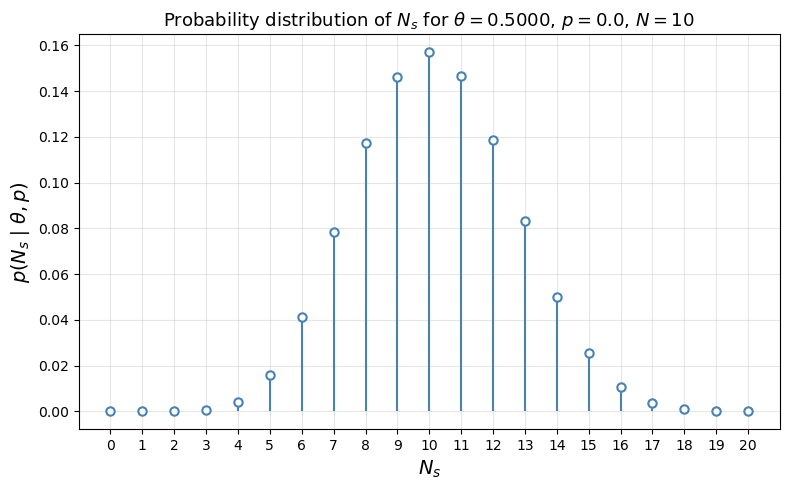

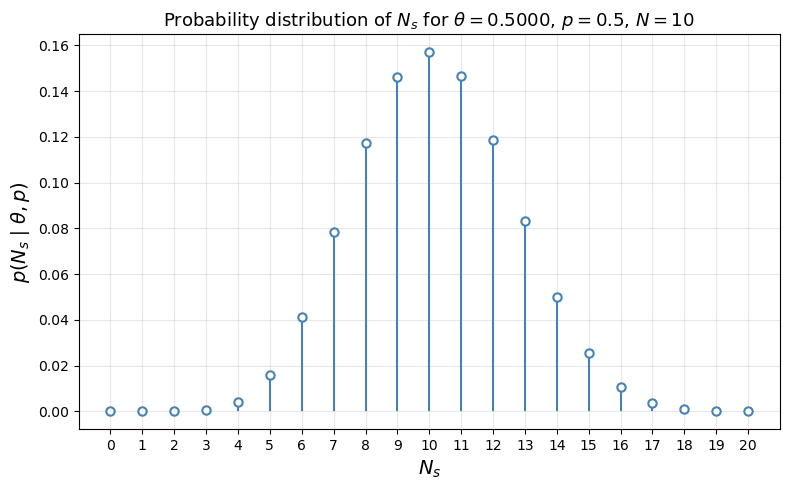

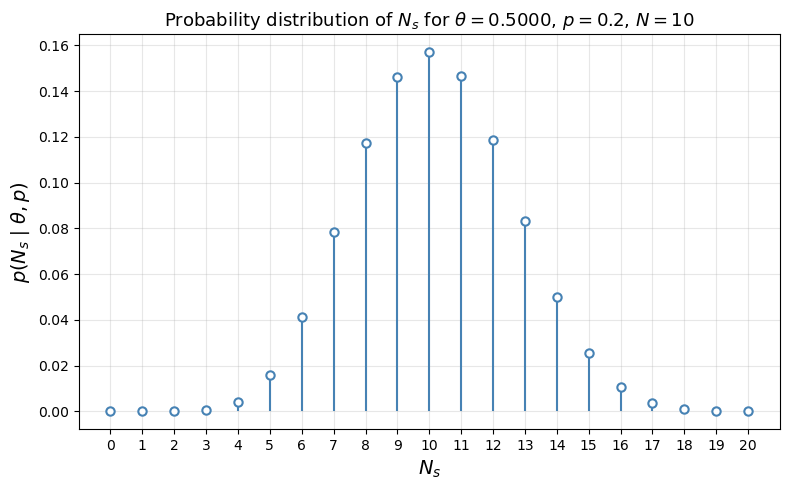

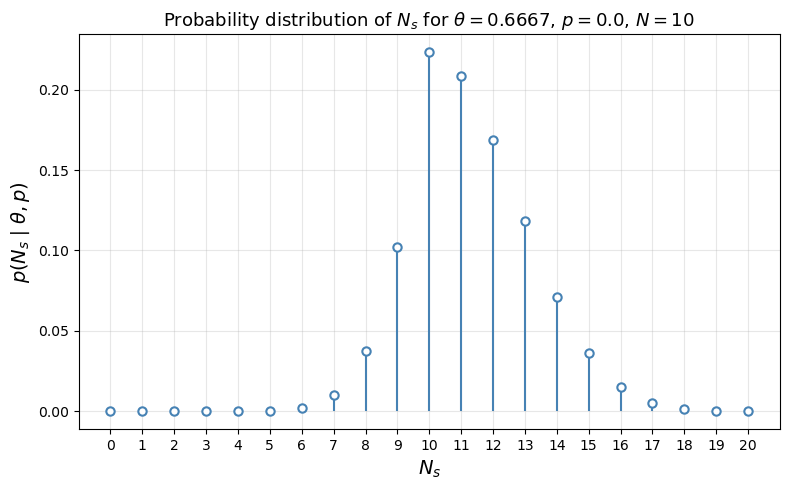

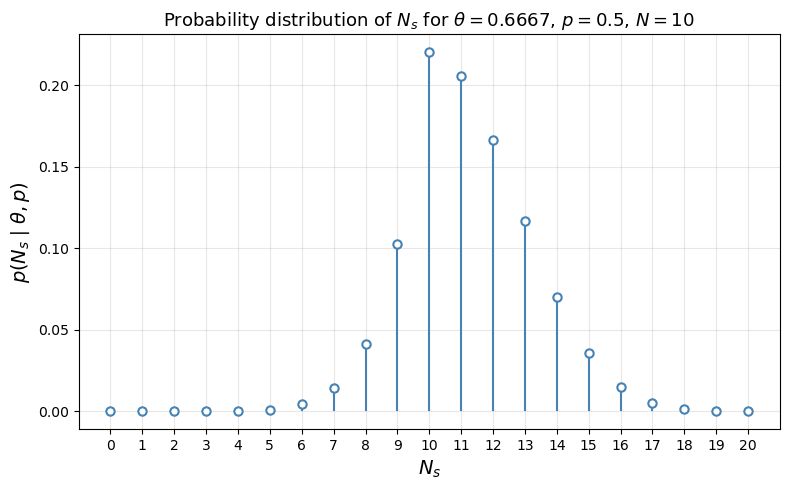

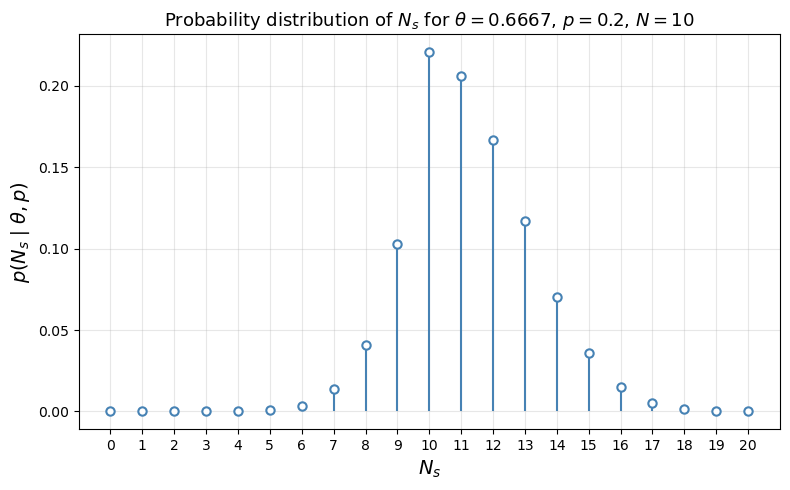

In [1]:
"""
Box 9: Pairs of Dice -- Application Example
============================================

This module computes posterior ratios and classifies observed sequences
of sums as belonging to a fair pair of coins (theta1 = 1/2) or a biased
pair (theta2 = 2/3), under various flipping probabilities p.

It also computes and plots the distribution of the total sum N_s.

Uses the sufficient-statistic formulation with binomial multiplicities
to avoid enumerating all 2^N x 2^N (z, f) pairs, making the computation
fast enough to generate plots for many (theta, p) combinations.


Distribution of N_s
-------------------

Definition
~~~~~~~~~~

N_s = sum_{n=1}^{N} S_n is the **total sum of the recorded values
across all N throws**, where each S_n = X_n + Y_n in {0, 1, 2} is
the sum of the two coins on throw n.

So N_s is the sum of N i.i.d. random variables taking values in
{0, 1, 2}, and therefore:

    N_s in {0, 1, 2, ..., 2N},

with the exact shape depending on theta (the coin bias) and p (the
flip probability).


Marginal distribution of a single throw S_n
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

For a single throw S_n = X_n + Y_n, since X_n, Z_n ~ Bernoulli(theta)
i.i.d., and Y_n = Z_n XOR F_n where F_n ~ Bernoulli(p):

    P(S_n = 0) = P(X_n = 0) * P(Y_n = 0)
               = (1 - theta) * [(1 - theta)(1 - p) + theta * p]

    P(S_n = 1) = (1 - theta) * [theta(1 - p) + (1 - theta) * p]
               + theta * [(1 - theta)(1 - p) + theta * p]

    P(S_n = 2) = theta * [theta(1 - p) + (1 - theta) * p]

For p = 0 (no flipping), these simplify to:

    P(S_n = 0) = (1 - theta)^2
    P(S_n = 1) = 2 * theta * (1 - theta)
    P(S_n = 2) = theta^2

i.e., S_n ~ Binomial(2, theta) when p = 0.

For p = 1/2, the flip makes Y_n uniform, so:

    P(S_n = 0) = (1 - theta) / 2
    P(S_n = 1) = 1 / 2
    P(S_n = 2) = theta / 2


The distribution of N_s
~~~~~~~~~~~~~~~~~~~~~~~

Sum of i.i.d. variables
^^^^^^^^^^^^^^^^^^^^^^^

Since the N throws are independent and identically distributed:

    N_s = sum_{n=1}^{N} S_n,    S_n ~ i.i.d. pmf(s; theta, p)

so N_s is a sum of N i.i.d. discrete random variables on {0, 1, 2}.

Exact pmf (via convolution)
^^^^^^^^^^^^^^^^^^^^^^^^^^^

The exact pmf is the N-fold convolution of the single-throw pmf:

    p(N_s = k | theta, p)
        = sum over (a, b) with a + b <= N and a + 2b = k
          of [ N! / (a! b! (N - a - b)!) ]
             * p_0^{N-a-b} * p_1^a * p_2^b

where p_0 = P(S_n = 0), p_1 = P(S_n = 1), p_2 = P(S_n = 2),
a = number of throws with S_n = 1,
b = number of throws with S_n = 2,
c = N - a - b = number of throws with S_n = 0.

This matches exactly the `probability_distribution_of_Ns` function
below (the `count` variable is the number of ternary sequences with
sum N_s, which is precisely this multinomial count).

Mean and variance
^^^^^^^^^^^^^^^^^

Using linearity of expectation, and because

    Y_n ~ Bernoulli(theta * (1 - p) + (1 - theta) * p),

we have:

    E[S_n] = E[X_n] + E[Y_n]
           = theta + theta * (1 - p) + (1 - theta) * p
           = 2 * theta * (1 - p) + p

Therefore:

    E[N_s] = N * [2 * theta * (1 - p) + p]

For p = 0, this reduces to the familiar E[N_s] = 2 * N * theta.

The variance of a single throw (using independence of X_n and Y_n) is:

    Var(S_n) = Var(X_n) + Var(Y_n)
             = theta * (1 - theta)
               + [theta * (1 - p) + (1 - theta) * p]
                 * [1 - theta * (1 - p) - (1 - theta) * p]

and because the throws are i.i.d.:

    Var(N_s) = N * Var(S_n)

For p = 0, this reduces to Var(N_s) = 2 * N * theta * (1 - theta)
-- the binomial variance.

Entropy
^^^^^^^

The entropy of N_s is:

    E(N_s) = - sum_{k=0}^{2N} p(N_s = k) * log p(N_s = k)

The maximum possible entropy is log(2N + 1). For N = 10, that is
log(21) ~ 3.04. The reported values (2.22 to 2.56) are below this,
indicating the distribution is concentrated.

Behavior in the limits
^^^^^^^^^^^^^^^^^^^^^^

- p = 0 and theta = 1/2:
    S_n ~ Binomial(2, 1/2), so N_s ~ Binomial(20, 1/2).
    Mean = 10, variance = 5, entropy ~ 2.71.

- p = 1/2:
    Y_n is uniform, so S_n has pmf ((1-theta)/2, 1/2, theta/2).
    The distribution becomes more spread out and the entropy increases.

- theta -> 0 or theta -> 1:
    The distribution concentrates near N_s = 0 or N_s = 2N
    (or near N_s = N when p dominates).

- N -> infinity:
    By the Central Limit Theorem (since Var(S_n) > 0),

        (N_s - N * mu_S) / (sqrt(N) * sigma_S) -> N(0, 1)

    so N_s becomes approximately normal.


Intuition
~~~~~~~~~

The distribution of N_s is essentially a compromise between two
binomials:

- The first coin contributes X_n ~ Bernoulli(theta), giving a
  Binomial(N, theta) contribution.

- The second coin contributes Y_n, which is a flipped version of
  Z_n ~ Bernoulli(theta). The flip with probability p effectively
  mixes Z_n toward Bernoulli(1/2) as p -> 1/2.

When p = 0:   Y_n = Z_n ~ Bernoulli(theta),
              so N_s ~ Binomial(2N, theta).

When p = 1/2: Y_n ~ Bernoulli(1/2) independent of theta,
              so N_s is the sum of Binomial(N, theta) and
              Binomial(N, 1/2).

When p = 1:   Y_n = 1 - Z_n ~ Bernoulli(1 - theta),
              so N_s ~ Binomial(N, theta) + Binomial(N, 1 - theta).

This is why the "effect of theta on N_s" matters for classification:
as p grows, the second coin carries less information about theta,
and the two hypotheses theta1 = 1/2 vs theta2 = 2/3 become harder
to distinguish. This is visible in the posterior ratios: at p = 0,
the sequence [2,2,2,2,2,0,0,0,0,0] gives a ratio of 1.80 in favor
of theta2; at larger p, the ratio shrinks toward 1.
"""

import numpy as np
from math import comb
import matplotlib.pyplot as plt


# ============================================================
# Fast marginal likelihood
# ============================================================

def marginal_likelihood_fast(s, theta, p, N):
    """
    Compute p(s | theta, p) efficiently using sufficient statistics.

    Sums over N_z, N_zf, N_f with binomial multiplicities instead of
    enumerating all 2^N x 2^N (z, f) pairs.

    Parameters
    ----------
    s : list of int
        Observed sums (length N).
    theta : float
        Probability of heads.
    p : float
        Probability of flipping the second coin.
    N : int
        Number of throws.

    Returns
    -------
    float
        The marginal likelihood p(s | theta, p).
    """
    N_s = sum(s)
    total = 0.0

    for N_z in range(N + 1):
        # multiplicity of z sequences with sum N_z
        mult_z = comb(N, N_z)
        # prior factor for z (theta enters twice per z: once for X, once for Z)
        factor_z = theta ** (2 * N_z) * (1 - theta) ** (2 * (N - N_z))

        for k in range(N_z + 1):                      # k = N_zf
            mult_k = comb(N_z, k)
            for j in range(k, k + (N - N_z) + 1):     # j = N_f
                mult_j = comb(N - N_z, j - k)

                N_x = N_s - N_z + 2 * k - j
                if N_x < 0 or N_x > N:
                    continue

                prob_f = p ** j * (1 - p) ** (N - j)
                prob_x = theta ** N_x * (1 - theta) ** (N - N_x)

                total += mult_z * factor_z * mult_k * mult_j * prob_f * prob_x

    return total


# ============================================================
# Posterior ratio and classification
# ============================================================

def posterior_ratio_fast(s, theta1, theta2, p, N, prior1=0.5, prior2=0.5):
    """
    Compute the posterior ratio p(theta1 | s, p) / p(theta2 | s, p).

    Parameters
    ----------
    s : list of int
        Observed sums (length N).
    theta1 : float
        Probability of heads for the first hypothesis.
    theta2 : float
        Probability of heads for the second hypothesis.
    p : float
        Probability of flipping the second coin.
    N : int
        Number of throws.
    prior1 : float
        Prior probability of theta1.
    prior2 : float
        Prior probability of theta2.

    Returns
    -------
    float
        The posterior ratio.
    """
    lik1 = marginal_likelihood_fast(s, theta1, p, N)
    lik2 = marginal_likelihood_fast(s, theta2, p, N)
    return (lik1 * prior1) / (lik2 * prior2)


def classify_sequence_fast(s, theta1, theta2, p, N, prior1=0.5, prior2=0.5):
    """
    Classify the observed sequence s as belonging to theta1 or theta2.

    Returns
    -------
    str
        'theta1' or 'theta2'.
    """
    ratio = posterior_ratio_fast(s, theta1, theta2, p, N, prior1, prior2)
    return 'theta1' if ratio > 1 else 'theta2'


# ============================================================
# Distribution of N_s over all ternary sequences
# ============================================================

def probability_distribution_of_Ns(theta, p, N):
    """
    Compute p(N_s | theta, p) for N_s = 0, ..., 2N by aggregating
    over all ternary sequences s of length N.

    Exploits the fact that p(s | theta, p) depends on s only through N_s,
    so we compute it once per N_s and multiply by the number of ternary
    sequences of length N with that sum.

    Returns
    -------
    N_s_values : ndarray of int
        Values 0, 1, ..., 2N.
    probabilities : ndarray of float
        Corresponding p(N_s | theta, p), normalized to sum to 1.
    """
    N_s_values = np.arange(0, 2 * N + 1)
    probabilities = np.zeros(2 * N + 1)

    for N_s in N_s_values:
        # Representative s: N_s ones and (N - N_s) zeros
        s = [1] * int(N_s) + [0] * int(N - N_s)
        s = s[:N]

        # Number of ternary sequences of length N with sum N_s:
        # coefficient of x^{N_s} in (1 + x + x^2)^N
        count = 0
        for a in range(N + 1):            # a ones
            for b in range(N + 1):        # b twos
                if a + b <= N and a + 2 * b == N_s:
                    count += comb(N, a) * comb(N - a, b)

        probabilities[N_s] = count * marginal_likelihood_fast(s, theta, p, N)

    # Normalize
    total = probabilities.sum()
    if total > 0:
        probabilities /= total

    return N_s_values, probabilities


# ============================================================
# Analysis helpers
# ============================================================

def analyze_sequences(sequences, theta1, theta2, p, N,
                      prior1=0.5, prior2=0.5,
                      label1='theta1 (fair)', label2='theta2 (biased)'):
    """
    Print posterior ratio and decision for each sequence.
    """
    for s in sequences:
        ratio = posterior_ratio_fast(s, theta1, theta2, p, N, prior1, prior2)
        decision = label1 if ratio > 1 else label2
        print(f"Sequence: {s}")
        print(f"  Posterior ratio: {ratio:.4f}")
        print(f"  Decision: {decision}")
        print()


# ============================================================
# Visualization (stem plots)
# ============================================================

def plot_probability_distribution(theta, p, N, save_path=None):
    """
    Plot p(N_s | theta, p) as a stem plot.

    Parameters
    ----------
    theta : float
        Probability of heads.
    p : float
        Probability of flipping the second coin.
    N : int
        Number of throws.
    save_path : str or None
        If given, save the figure to this path.
    """
    N_s_values, probabilities = probability_distribution_of_Ns(theta, p, N)

    fig, ax = plt.subplots(figsize=(8, 5))

    markerline, stemlines, baseline = ax.stem(
        N_s_values,
        probabilities,
        linefmt='-',
        markerfmt='o',
        basefmt=' ',
    )

    # Style the stem plot
    plt.setp(stemlines, color='steelblue', linewidth=1.5)
    plt.setp(markerline, color='steelblue', markersize=6,
             markerfacecolor='white', markeredgecolor='steelblue',
             markeredgewidth=1.5)

    ax.set_xlabel(r'$N_s$', fontsize=14)
    ax.set_ylabel(r'$p(N_s \mid \theta, p)$', fontsize=14)
    ax.set_title(
        rf'Probability distribution of $N_s$ for '
        rf'$\theta = {theta:.4f}$, $p = {p}$, $N = {N}$',
        fontsize=13,
    )
    ax.grid(True, alpha=0.3)
    ax.set_xticks(N_s_values)
    fig.tight_layout()

    if save_path is not None:
        fig.savefig(save_path, dpi=150, bbox_inches='tight')

    plt.show()


def plot_all_distributions(N, thetas, ps, save_dir=None):
    """
    Plot distributions for several (theta, p) combinations.

    Parameters
    ----------
    N : int
        Number of throws.
    thetas : list of float
        List of theta values.
    ps : list of float
        List of p values.
    save_dir : str or None
        If given, save each figure in this directory.
    """
    for theta in thetas:
        for p in ps:
            save_path = None
            if save_dir is not None:
                save_path = f"{save_dir}/dist_theta_{theta:.4f}_p_{p}.png"
            plot_probability_distribution(theta, p, N, save_path=save_path)


# ============================================================
# Main
# ============================================================

if __name__ == "__main__":
    # Parameters
    N = 10
    theta1 = 0.5
    theta2 = 2 / 3
    prior1 = 0.5
    prior2 = 0.5

    # Sequences from the problem
    sequences = [
        [1, 0, 1, 0, 1, 0, 1, 0, 1, 0],
        [2, 2, 2, 2, 2, 0, 0, 0, 0, 0],
    ]

    # ---- Questions 1 & 2: p = 0 (no flipping) ----
    print("=" * 60)
    print("Questions 1 & 2: p = 0 (no flipping)")
    print("=" * 60)
    analyze_sequences(sequences, theta1, theta2, p=0.0, N=N,
                      prior1=prior1, prior2=prior2)

    # ---- Question 3: p = 0.5 ----
    print("=" * 60)
    print("Question 3: p = 0.5 (flipping with probability 0.5)")
    print("=" * 60)
    analyze_sequences(sequences, theta1, theta2, p=0.5, N=N,
                      prior1=prior1, prior2=prior2)

    # ---- Question 3: p = 0.2 ----
    print("=" * 60)
    print("Question 3: p = 0.2 (flipping with probability 0.2)")
    print("=" * 60)
    analyze_sequences(sequences, theta1, theta2, p=0.2, N=N,
                      prior1=prior1, prior2=prior2)

    # ---- Plots (stem plots) ----
    print("Generating stem plots...")
    thetas_to_plot = [0.5, 2 / 3]
    ps_to_plot = [0.0, 0.5, 0.2]
    plot_all_distributions(N, thetas_to_plot, ps_to_plot)